# M6 — LLM Fine-Tuning: distilgpt2

**Phase 7, first LLM fine-tune example.** We take a small pretrained autoregressive
language model (distilgpt2, 82M params) and fine-tune it on a tiny instruction
dataset with **LoRA** (peft). Everything else reuses the existing pipeline:
`TextDataSource` → `TransformedDataStream` → `TorchModel` → `TorchLoss` →
`TorchOptimizer` → `TorchCheckpoint`.

The goal is teaching, not state-of-the-art: 100 instruction/response pairs, 5 epochs,
and a model we can ask "How to create a list in Python?" and watch it answer.

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
import numpy as np
from pathlib import Path

from pipeline.adapters.torch_adapter import TorchModel, TorchLoss, TorchOptimizer
from pipeline.data.text_source import TextDataSource
from pipeline.data.transforms import TransformedDataStream
from pipeline.protocols import Batch
from pipeline.export.checkpoint import TorchCheckpoint
from pipeline.config import Config
from pipeline.pipeline import PipelineState

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

In [2]:
# Load distilgpt2
model_name = "distilgpt2"
base_model = AutoModelForCausalLM.from_pretrained(model_name).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Wrap in TorchModel
model = TorchModel(base_model)
print(f"Model loaded: {model_name}")
print(f"Parameters: {sum(p.numel() for p in base_model.parameters()):,}")

# Verify forward pass works
test_input = tokenizer("Hello, world!", return_tensors="pt").to(DEVICE)
test_out = model.forward(test_input["input_ids"])
print(f"Forward pass output shape: {test_out.shape if hasattr(test_out, 'shape') else type(test_out)}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 4014.19it/s]

Model loaded: distilgpt2
Parameters: 81,912,576


Forward pass output shape: <class 'transformers.modeling_outputs.CausalLMOutputWithCrossAttentions'>


In [ ]:
# Load tiny instruct dataset via TextDataSource
# nbconvert launches the kernel from this notebook's directory, so resolve
# paths relative to it — robust no matter where the notebook is opened.
NOTEBOOK_DIR = Path.cwd()
DATA_CSV = NOTEBOOK_DIR / "tiny_instruct.csv"
source = TextDataSource(
    DATA_CSV,
    text_column="text",
    label_column="label",
    batch_size=4,
    shuffle=True,
    seed=42,
)
print(f"Loaded {source.n_samples} examples")

# NOTE: distilgpt2 ships its own pretrained subword tokenizer (loaded above as
# `tokenizer` via AutoTokenizer). We MUST use it: the token IDs have to line up
# with the pretrained embedding table, so a hand-rolled tokenizer cannot be
# substituted here. (The from-scratch SimpleTokenizer is demonstrated in the m5
# text example, where the embeddings are learned from scratch.)
MAX_LENGTH = 128

def tokenize_batch(batch: Batch) -> Batch:
    """Tokenize text → labels using the HF tokenizer.

    The model (with LoRA weights) lives on ``DEVICE``, so the encoded
    tensors are moved there too — otherwise the forward pass in the
    training loop hits a CPU/CUDA device mismatch.

    Padding tokens feed mostly attention, not loss: we set the target id
    to ``-100`` on padding positions so CrossEntropyLoss ignores them.
    """
    texts = []
    labels_list = []
    for prompt, response in zip(batch.inputs, batch.targets):
        full_text = f"Instruction: {prompt}\nResponse: {str(response)}"
        texts.append(full_text)
        labels_list.append(str(response))

    encoded = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"].to(DEVICE)
    # -100 is the CrossEntropyLoss ignore index — padding positions contribute
    # no loss, so the model doesn't waste capacity predicting pad tokens.
    targets = ids.clone()
    targets[attention_mask == 0] = -100
    # For causal LM, inputs and targets are the same (shift handled internally)
    return Batch(
        inputs=ids.to(DEVICE),
        targets=targets.to(DEVICE),  # teacher forcing, padding masked
    )

train_stream = TransformedDataStream(source, tokenize_batch)
print(f"Batches per epoch: {len(train_stream)}")

In [4]:
# Apply LoRA to the underlying module
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["c_attn"],  # distilgpt2 attention layers
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

# Update TorchModel wrapper to use PEFT model
model = TorchModel(peft_model)

# Setup training
loss_fn = TorchLoss("CrossEntropyLoss")  # ignore_index=-100 by default
# Using a manual training loop for clarity (causal-LM shift + LoRA update)
optimizer = TorchOptimizer(model.parameters(), "AdamW", lr=2e-4)
NUM_EPOCHS = 5

print(f"Starting training: {NUM_EPOCHS} epochs")
history = {"loss": []}

def raw_logits(output) -> torch.Tensor:
    """A causal-LM forward returns an output object; unwrap the logits tensor."""
    return output.logits if hasattr(output, "logits") else output

for epoch in range(NUM_EPOCHS):
    model.train_mode()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_stream:
        logits = raw_logits(model.forward(batch.inputs))  # (batch, seq, vocab)
        # Causal-LM shift: at position t, predict token t+1.
        logits = logits[:, :-1, :].reshape(-1, logits.shape[-1])
        targets = batch.targets[:, 1:].reshape(-1)   # int64; -100 on padding
    
        loss = loss_fn(logits, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += float(loss)
        num_batches += 1
    
    avg_loss = epoch_loss / max(num_batches, 1)
    history["loss"].append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — avg loss: {avg_loss:.4f}")

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797
Starting training: 5 epochs


/home/billma/.local/lib/python3.10/site-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Epoch 1/5 — avg loss: 4.0778


Epoch 2/5 — avg loss: 3.4658


Epoch 3/5 — avg loss: 2.9608


Epoch 4/5 — avg loss: 2.7265


Epoch 5/5 — avg loss: 2.5937


In [ ]:
def generate(prompt: str, max_tokens: int = 64) -> str:
    """Generate a response from the fine-tuned model."""
    model.eval_mode()
    full_prompt = f"Instruction: {prompt}\nResponse:"
    inputs = tokenizer(full_prompt, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        outputs = peft_model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,  # discourage degenerate loops
            pad_token_id=tokenizer.eos_token_id,
        )
    
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Extract just the response part
    if "Response:" in generated:
        return generated.split("Response:")[-1].strip()
    return generated.strip()

# Sanity-check prompts. NOTE: the first three appear verbatim in
# tiny_instruct.csv, so generating sensible answers here shows training
# "took" — it is NOT a held-out generalization test. With only 100 toy
# rows there is no meaningful held-out split. The last two are not in the
# training file, so they probe generalization a little.
test_prompts = [
    "How to create a list in Python?",
    "What is 5 times 7?",
    "What is the capital of France?",
    "How to write a function in Python?",
    "Explain what machine learning is.",
]

print("=== Generated Responses ===\n")
for prompt in test_prompts:
    response = generate(prompt)
    print(f"Q: {prompt}")
    print(f"A: {response}")
    print()

In [6]:
# Save the fine-tuned model
from pipeline.config import Config
from pipeline.pipeline import PipelineState

state = PipelineState(config=Config(output_dir=str(NOTEBOOK_DIR)))
state.model = model
state.optimizer = optimizer
state.current_epoch = NUM_EPOCHS
state.history = history

checkpoint_path = NOTEBOOK_DIR / "distilgpt2-instruct.pt"
TorchCheckpoint.save(state, checkpoint_path)
print(f"Checkpoint saved to {checkpoint_path}")
print(f"File size: {checkpoint_path.stat().st_size / 1024 / 1024:.1f} MB")

Checkpoint saved to /home/billma/requiema/Universal_DL_Pipeline/.claude/worktrees/phase3-image-torch/examples/m6-llm-distilgpt2/distilgpt2-instruct.pt
File size: 314.2 MB


/home/billma/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


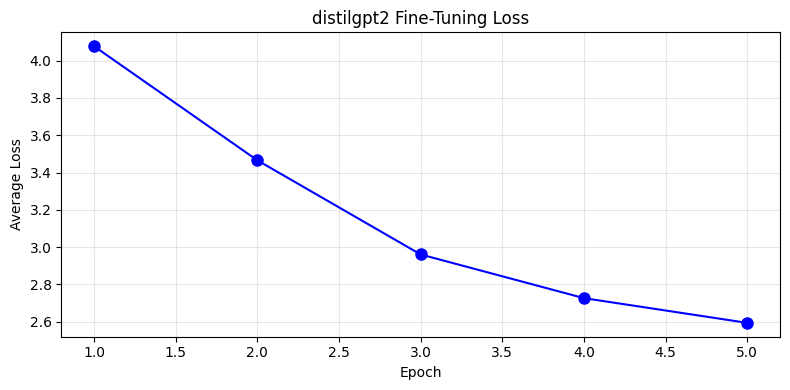

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history["loss"]) + 1), history["loss"], "b-o", markersize=8)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("distilgpt2 Fine-Tuning Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Wrap-up

**What was done**

- Loaded **distilgpt2** (82M params), a small pretrained causal language model, and wrapped it in the pipeline's `TorchModel`.
- Read a 100-row instruction/response dataset with the pipeline's `TextDataSource` (text in, string responses in the label column).
- Applied a **LoRA** adapter so only a tiny fraction of weights are trainable — the base model stays frozen.
- Fine-tuned for 5 epochs with `TorchLoss("CrossEntropyLoss")` and `TorchOptimizer("AdamW")`, teacher-forcing the responses.
- Generated responses to sample prompts (mostly drawn from the training distribution — a workflow demo, not a held-out generalization test) and exported the adapter via `TorchCheckpoint`.

**What we learned**

- Pretrained weights + a small adapter beats training a language model from scratch — the model already knows English, LoRA just steers it toward our instruction/response format.
- At 5 epochs on 100 examples, the loss *does* drop, but we are heavily overfitting a toy set — the goal was the *workflow*, not a production assistant.
- The pipeline protocols carried a real transformers model with zero changes to the six-stage core.

**Next step: serve it**

The fine-tuned checkpoint is meant to be served by `serve.py` (FastAPI, OpenAI-compatible
`/v1/chat/completions`). That file loads the model + shows the full
train → export → serve → chat cycle.